# Car Price Data Analysis and Linear Regression (Simple)

This notebook follows a simple stage-based workflow:
1. Load dataset
2. Inspect structure and quality
3. Clean and prepare data
4. Perform exploratory data analysis (plots)
5. Build Linear Regression model
6. Evaluate performance
7. Explain model coefficients
8. Export model as `model.pkl`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


## Stage 1: Load Dataset

In [2]:
DATA_PATH = r"C:\Users\HP\Desktop\codex\car_price_prediction.csv"
raw_df = pd.read_csv(DATA_PATH)
print("Dataset loaded from:", DATA_PATH)
print("Shape:", raw_df.shape)
display(raw_df.head())


Dataset loaded from: C:\Users\HP\Desktop\codex\car_price_prediction.csv
Shape: (19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## Stage 2: Inspect Data

In [3]:
print("Columns:")
print(raw_df.columns.tolist())

print("\nDtypes:")
display(raw_df.dtypes.to_frame("dtype"))

print("\nMissing values per column:")
display(raw_df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", raw_df.duplicated().sum())


Columns:
['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags']

Dtypes:


,dtype
ID,int64
Price,int64
Levy,object
Manufacturer,object
Model,object
Prod. year,int64
Category,object
Leather interior,object
Fuel type,object
Engine volume,object



Missing values per column:


,missing_count
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0



Duplicate rows: 313


## Stage 3: Clean and Prepare Data

In [4]:
df = raw_df.copy()

# Standardize column names
df.columns = [c.strip().lower().replace(" ", "_").replace(".", "") for c in df.columns]

# Fix values and types
df["levy"] = df["levy"].replace("-", np.nan)
df["levy"] = pd.to_numeric(df["levy"], errors="coerce")

df["mileage"] = pd.to_numeric(
    df["mileage"].astype(str).str.replace(" km", "", regex=False).str.replace(",", "", regex=False),
    errors="coerce"
)

df["engine_volume_turbo"] = df["engine_volume"].astype(str).str.contains("Turbo", case=False, na=False).astype(int)
df["engine_volume_num"] = pd.to_numeric(
    df["engine_volume"].astype(str).str.extract(r"([0-9]+\.?[0-9]*)")[0],
    errors="coerce"
)

df["doors"] = df["doors"].astype(str).replace({"02-Mar": "2-3", "04-May": "4-5", ">5": "5+"})
df["car_age"] = (2026 - df["prod_year"]).clip(lower=0)

# Drop less useful raw columns after feature extraction
df = df.drop(columns=["id", "engine_volume"], errors="ignore")

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

print("Cleaned shape:", df.shape)
print("\nMissing values after cleaning:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))
display(df.head())


Cleaned shape: (15725, 19)

Missing values after cleaning:


,missing_count
levy,5684
price,0
gear_box_type,0
engine_volume_num,0
engine_volume_turbo,0
airbags,0
color,0
wheel,0
doors,0
drive_wheels,0


,price,levy,manufacturer,model,prod_year,category,leather_interior,fuel_type,mileage,cylinders,gear_box_type,drive_wheels,doors,wheel,color,airbags,engine_volume_turbo,engine_volume_num,car_age
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,186005,6.0,Automatic,4x4,4-5,Left wheel,Silver,12,0,3.5,16
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,192000,6.0,Tiptronic,4x4,4-5,Left wheel,Black,8,0,3.0,15
2,8467,NaN,HONDA,FIT,2006,Hatchback,No,Petrol,200000,4.0,Variator,Front,4-5,Right-hand drive,Black,2,0,1.3,20
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,168966,4.0,Automatic,4x4,4-5,Left wheel,White,0,0,2.5,15
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,91901,4.0,Automatic,Front,4-5,Left wheel,Silver,4,0,1.3,12


## Stage 4: Exploratory Data Analysis (EDA)

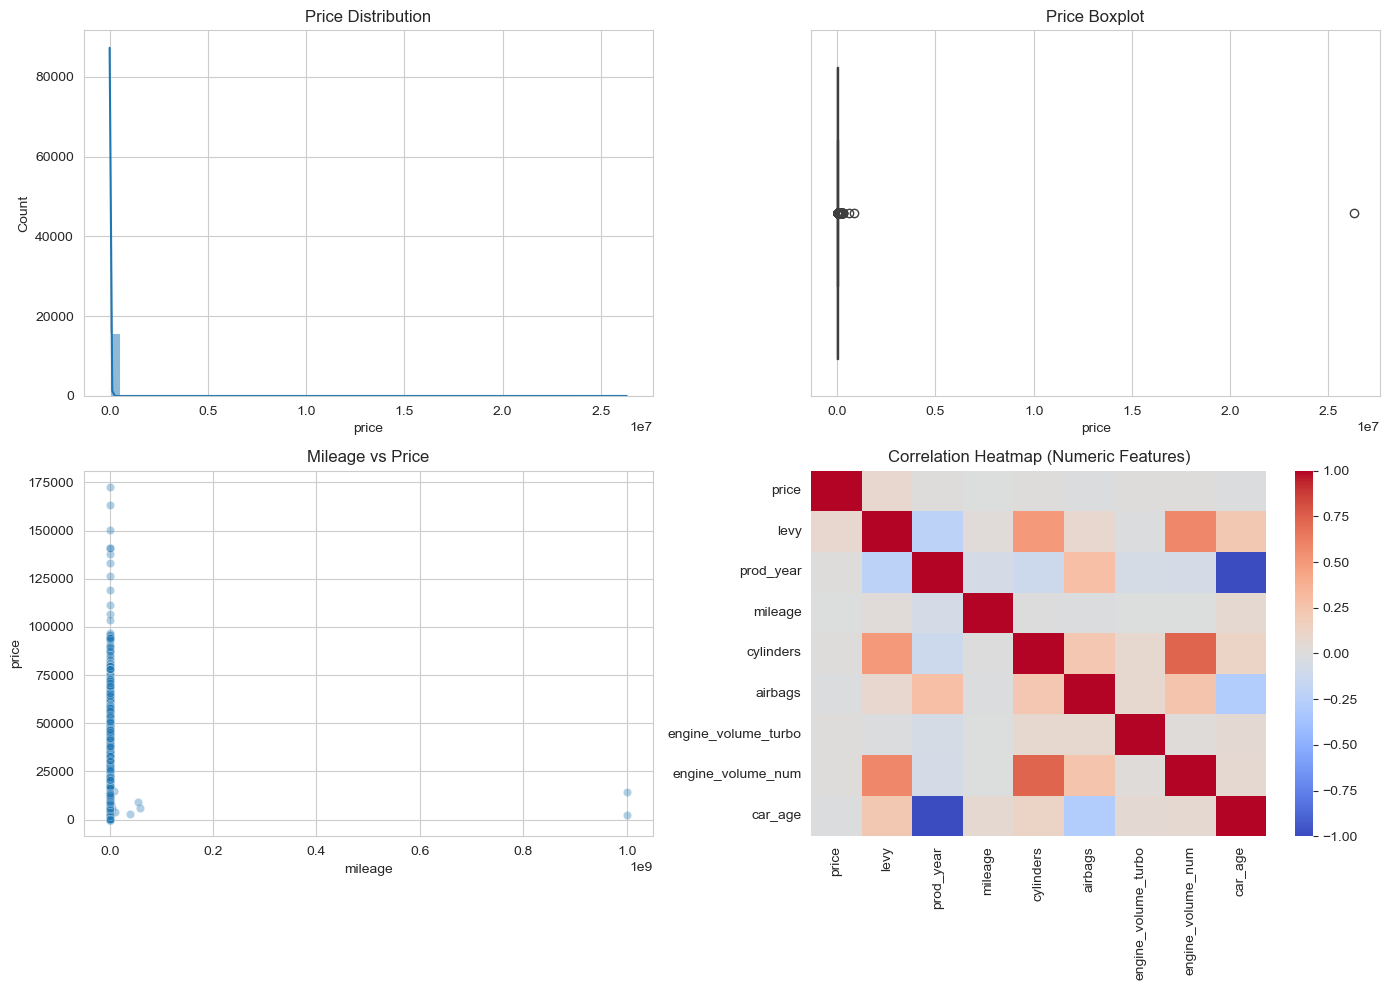

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Price distribution
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Price Distribution")

# 2) Price boxplot (outlier view)
sns.boxplot(x=df["price"], ax=axes[0, 1])
axes[0, 1].set_title("Price Boxplot")

# 3) Mileage vs Price (sample for readability)
plot_sample = df[["mileage", "price"]].dropna()
if len(plot_sample) > 3000:
    plot_sample = plot_sample.sample(3000, random_state=42)
sns.scatterplot(data=plot_sample, x="mileage", y="price", alpha=0.35, ax=axes[1, 0])
axes[1, 0].set_title("Mileage vs Price")

# 4) Correlation heatmap (numeric only)
num_cols = df.select_dtypes(include=["number"]).columns
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap (Numeric Features)")

plt.tight_layout()
plt.show()


## Stage 5: Build Linear Regression Model

In [6]:
target_col = "price"
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("linear_regression", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model trained successfully.")
print("Train rows:", len(X_train), "| Test rows:", len(X_test))


Model trained successfully.
Train rows: 12580 | Test rows: 3145


## Stage 6: Evaluate Model Performance

In [7]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2:   {r2:.4f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


R2:   -0.0132
MSE:  323414376.78
RMSE: 17983.73


## Stage 7: Plot Regression Line (Simple View with Mileage)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


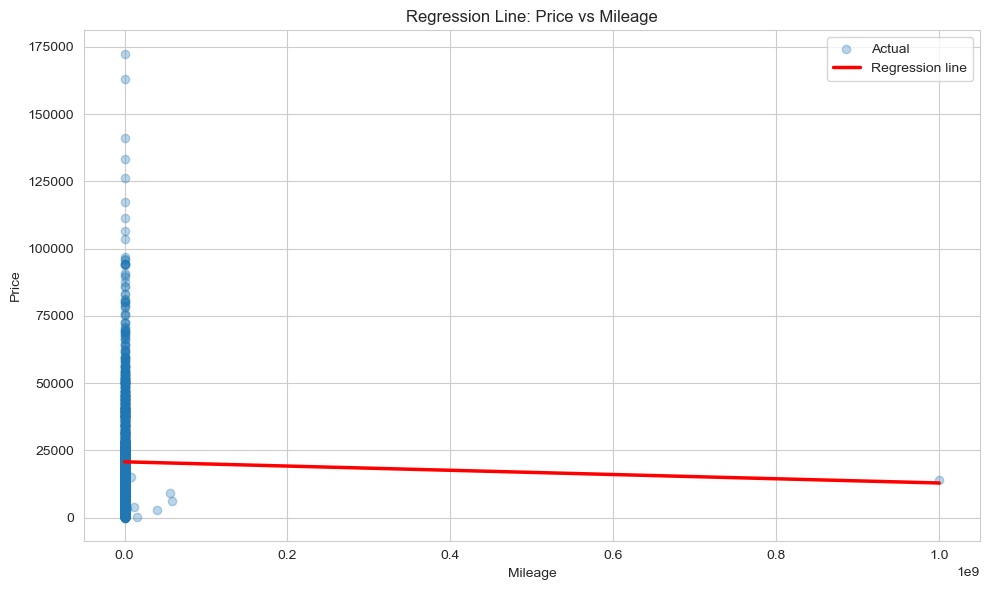

In [8]:
# For a clean regression-line visualization, use one feature: mileage
simple_df = df[["mileage", "price"]].dropna().copy()

X_simple = simple_df[["mileage"]]
y_simple = simple_df["price"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train_s)

line_x = np.linspace(X_test_s["mileage"].min(), X_test_s["mileage"].max(), 300)
line_y = simple_lr.predict(line_x.reshape(-1, 1))

plot_points = pd.DataFrame({"mileage": X_test_s["mileage"], "price": y_test_s})
if len(plot_points) > 2000:
    plot_points = plot_points.sample(2000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(plot_points["mileage"], plot_points["price"], alpha=0.3, label="Actual")
plt.plot(line_x, line_y, color="red", linewidth=2.5, label="Regression line")
plt.title("Regression Line: Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## Stage 8: Explain Coefficients

In [9]:
pre = model.named_steps["preprocessor"]
lr = model.named_steps["linear_regression"]

feature_names = pre.get_feature_names_out()
coef_values = lr.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef_values,
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

print("Top positive coefficients (increase predicted price):")
display(coef_df.sort_values("coefficient", ascending=False).head(10))

print("Top negative coefficients (decrease predicted price):")
display(coef_df.sort_values("coefficient", ascending=True).head(10))


Top positive coefficients (increase predicted price):


,feature,coefficient,abs_coefficient
0,num__levy,1.309954e-10,1.309954e-10
1,num__prod_year,4.140180e-12,4.140180e-12
1486,cat__fuel_type_Diesel,9.227267e-13,9.227267e-13
3,num__cylinders,7.114807e-13,7.114807e-13
6,num__engine_volume_num,6.679642e-13,6.679642e-13
504,cat__model_Combo,6.039058e-13,6.039058e-13
1474,cat__category_Goods wagon,5.660499e-13,5.660499e-13
1499,cat__doors_2-3,5.601151e-13,5.601151e-13
50,cat__manufacturer_OPEL,5.094770e-13,5.094770e-13
1506,cat__color_Blue,4.868074e-13,4.868074e-13


Top negative coefficients (decrease predicted price):


,feature,coefficient,abs_coefficient
2,num__mileage,-7.869549e-06,7.869549e-06
7,num__car_age,-4.140180e-12,4.140180e-12
4,num__airbags,-3.494614e-12,3.494614e-12
1481,cat__category_Sedan,-6.558092e-13,6.558092e-13
1500,cat__doors_4-5,-5.621825e-13,5.621825e-13
1492,cat__gear_box_type_Automatic,-5.382154e-13,5.382154e-13
1490,cat__fuel_type_Petrol,-4.304517e-13,4.304517e-13
1475,cat__category_Hatchback,-4.003869e-13,4.003869e-13
1503,cat__wheel_Right-hand drive,-3.154182e-13,3.154182e-13
1516,cat__color_Silver,-3.062205e-13,3.062205e-13


### Coefficient Interpretation Notes

- A **positive** coefficient means that feature tends to increase predicted price (all else equal).
- A **negative** coefficient means that feature tends to decrease predicted price.
- For one-hot encoded categories, each coefficient is relative to a baseline category.
- Larger absolute coefficient values indicate stronger linear influence.


## Stage 9: Export Trained Model as `model.pkl`

In [10]:
model_bundle = {
    "model": model,
    "feature_columns": X.columns.tolist(),
    "target_column": target_col,
    "description": "Linear Regression pipeline with preprocessing"
}

MODEL_PATH = r"C:\Users\HP\Desktop\codex\model.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model_bundle, f)

print("Model exported successfully to:", MODEL_PATH)


Model exported successfully to: C:\Users\HP\Desktop\codex\model.pkl
